# 05 — Projection, truncation, and ringing

Notebook 04 ended on a discouraging note: an L2 reconstruction of a studio
environment looks like coloured mush. This notebook takes that seriously —
measures exactly how bad truncation is, shows the artefact it produces
(**ringing**, including physically impossible negative light), and fixes it.

Everything here is about representing **radiance**. Notebook 06 will show that
irradiance — the thing we actually need — is a much easier problem.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import shlib as sh
import shplot as sp

sp.use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=110)

In [2]:
import shscene as ss

ENVS = ["gradient", "studio", "split", "sun"]
DESCRIPTION = {
    "gradient": "smooth sky/ground — low frequency",
    "studio":   "three area lights — mid frequency",
    "split":    "hard hemisphere step — a spherical square wave",
    "sun":      "tiny 120x-bright disc — near-delta, the worst case",
}
for k in ENVS:
    print(f"{k:>9}  {DESCRIPTION[k]}")

 gradient  smooth sky/ground — low frequency
   studio  three area lights — mid frequency
    split  hard hemisphere step — a spherical square wave
      sun  tiny 120x-bright disc — near-delta, the worst case


(<Figure size 1155x550 with 4 Axes>,
 array([[<Axes: title={'left': 'gradient — max radiance 0.9'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'studio — max radiance 9.0'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>],
        [<Axes: title={'left': 'split — max radiance 1.6'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'sun — max radiance 120.3'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>]],
       dtype=object))

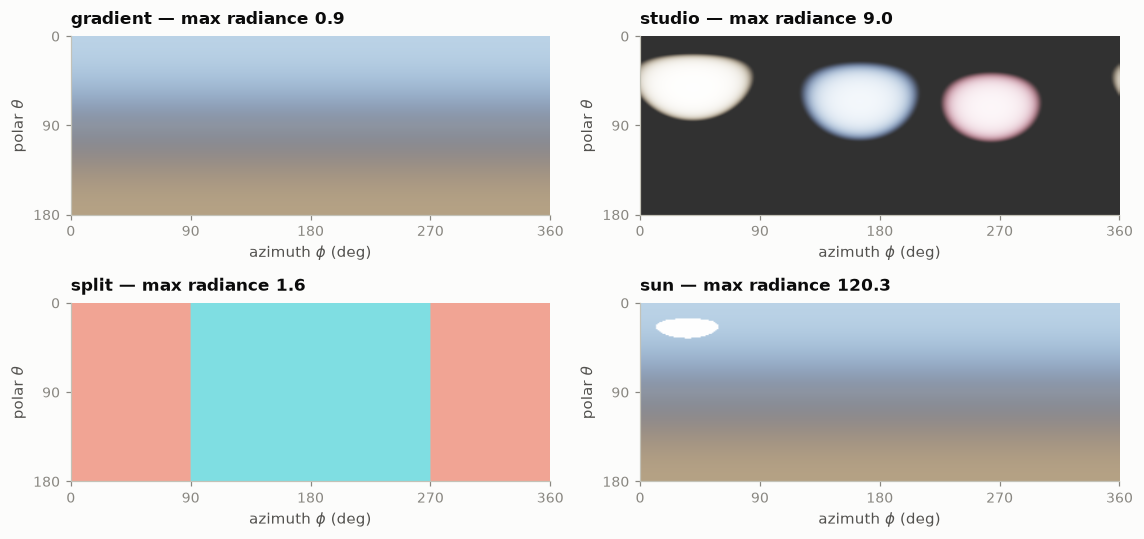

In [3]:
# What we're trying to represent.
imgs, titles = [], []
for k in ENVS:
    im = sh.env_to_equirect(ss.ENVIRONMENTS[k], 300, 150)
    imgs.append(ss.srgb_encode(ss.tonemap(im, 1.0, "aces")))
    titles.append(f"{k} — max radiance {im.max():.1f}")
sp.show_images(imgs, titles, cols=2, figsize=(10.5, 5.0))

## 1. Truncation, band by band

Project each environment to a high band, then reconstruct using progressively more
coefficients. Because the basis is orthonormal, truncating is *literally* just
dropping the tail of the coefficient array — no re-fitting needed.

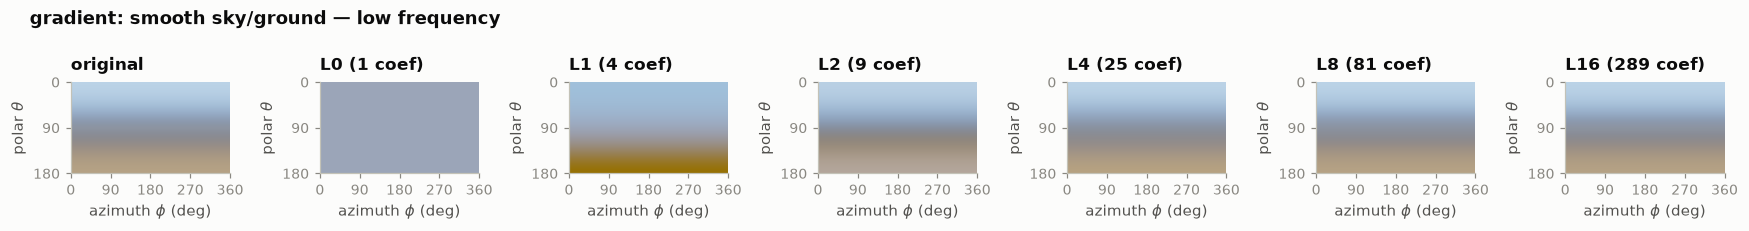

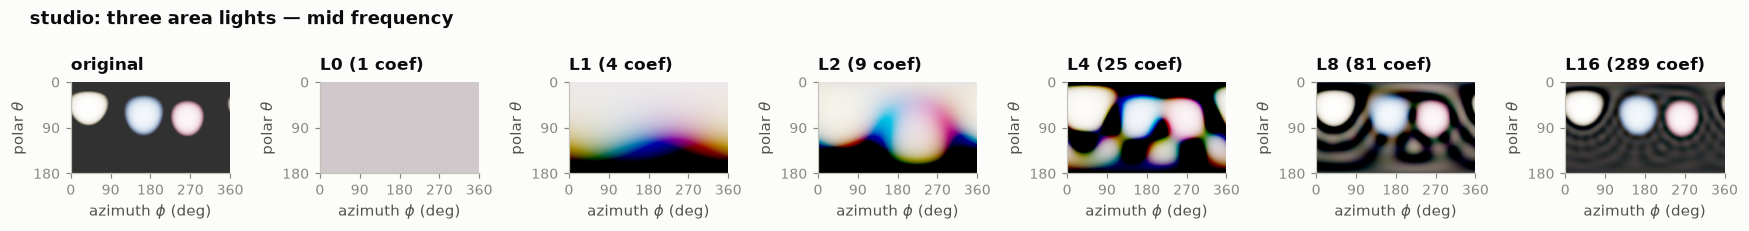

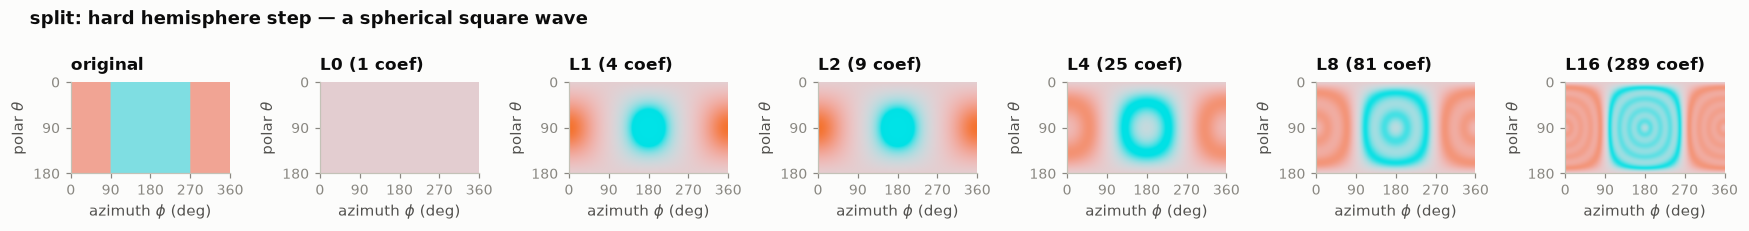

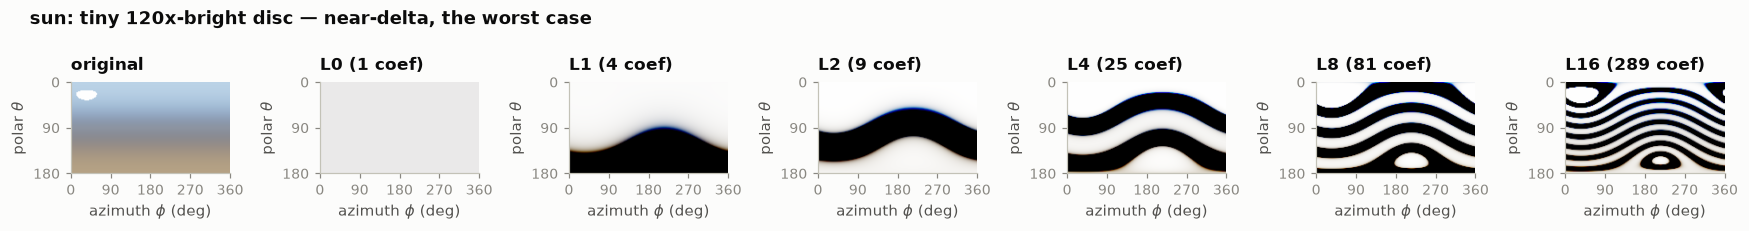

In [4]:
LMAX = 16
coeffs = {k: sh.project_env(ss.ENVIRONMENTS[k], LMAX, n_samples=500_000)
          for k in ENVS}

def recon_row(key, bands=(0, 1, 2, 4, 8, 16), w=200, h=100):
    truth = sh.env_to_equirect(ss.ENVIRONMENTS[key], w, h)
    scale = truth.max()
    out = [ss.srgb_encode(ss.tonemap(truth, 1.0, "aces"))]
    names = ["original"]
    for L in bands:
        rec = sh.sh_to_equirect(coeffs[key][:(L+1)**2], w, h)
        out.append(ss.srgb_encode(ss.tonemap(rec, 1.0, "aces")))
        names.append(f"L{L} ({(L+1)**2} coef)")
    return out, names

for k in ENVS:
    imgs, names = recon_row(k)
    fig, _ = sp.show_images(imgs, names, cols=7, figsize=(16.0, 2.1),
                            suptitle=f"{k}: {DESCRIPTION[k]}")

The `gradient` row is essentially converged by L2 — it *is* a low-frequency
function. The `split` and `sun` rows are still visibly wrong at L16.

Now quantify it. Parseval (notebook 02) says the fraction of energy retained is
just the fraction of squared coefficients retained, so we can measure convergence
without reconstructing anything.

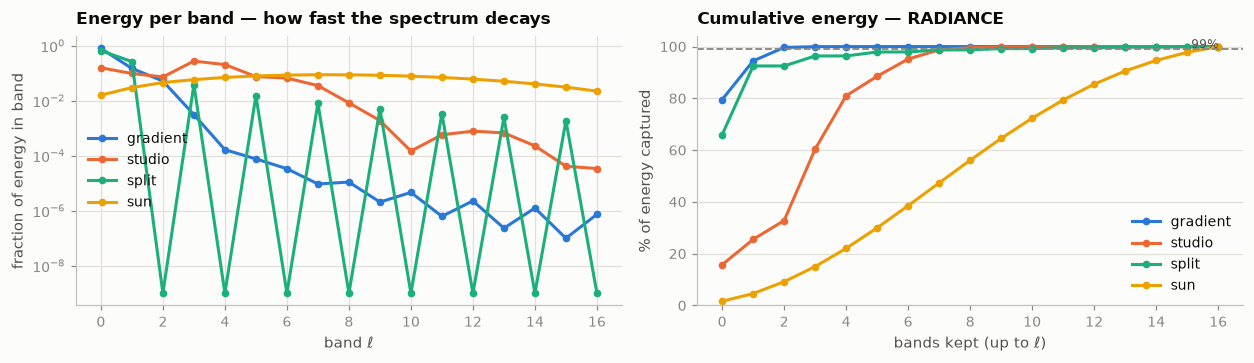

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))

for i, k in enumerate(ENVS):
    c = coeffs[k]
    energy = np.array([ (c[l*l:(l+1)*(l+1)]**2).sum() for l in range(LMAX+1) ])
    axes[0].semilogy(range(LMAX+1), np.maximum(energy/energy.sum(), 1e-9),
                     "o-", color=sp.SERIES[i], label=k, ms=4)
    cum = np.cumsum(energy) / energy.sum()
    axes[1].plot(range(LMAX+1), cum*100, "o-", color=sp.SERIES[i], label=k, ms=4)

axes[0].set_xlabel("band $\\ell$"); axes[0].set_ylabel("fraction of energy in band")
axes[0].set_title("Energy per band — how fast the spectrum decays")
axes[0].legend(); axes[0].grid(True, which="both", axis="both")

axes[1].axhline(99, color=sp.MUTED, ls="--", lw=1.2)
axes[1].text(LMAX, 99.4, "99%", ha="right", fontsize=8, color=sp.SECONDARY)
axes[1].set_xlabel("bands kept (up to $\\ell$)"); axes[1].set_ylabel("% of energy captured")
axes[1].set_title("Cumulative energy — RADIANCE")
axes[1].set_ylim(0, 104); axes[1].legend()
fig.tight_layout()

In [6]:
print("Percent of RADIANCE energy captured")
print(f"{'environment':<11}" + "".join(f"{'L'+str(L):>9}" for L in (0,1,2,3,4,8,16)))
print("-" * 76)
for k in ENVS:
    c = coeffs[k]
    e = np.array([(c[l*l:(l+1)*(l+1)]**2).sum() for l in range(LMAX+1)])
    cum = np.cumsum(e)/e.sum()
    print(f"{k:<11}" + "".join(f"{cum[L]*100:>8.2f}%" for L in (0,1,2,3,4,8,16)))

Percent of RADIANCE energy captured
environment       L0       L1       L2       L3       L4       L8      L16
----------------------------------------------------------------------------
gradient      79.51%   94.46%   99.66%   99.97%   99.99%  100.00%  100.00%
studio        15.74%   25.51%   32.81%   60.40%   81.00%   99.56%  100.00%
split         65.94%   92.51%   92.51%   96.38%   96.38%   98.72%  100.00%
sun            1.60%    4.59%    9.17%   15.01%   22.04%   56.11%  100.00%


Read the `sun` row: at L2 we have captured only a fraction of the radiance energy.
A near-delta function has an essentially flat spectrum — that is what "delta
function" *means* in frequency terms, and no finite band count will capture it.

**If light probes had to reproduce radiance, they would not work.** Hold that
thought for notebook 06.

## 2. Ringing — the artefact that bites in production

Truncation is a brick-wall low-pass filter, and brick-wall filters ring. On the
sphere this is the same Gibbs phenomenon we saw on the square wave in notebook 02.

The consequence is not just cosmetic. It produces **negative radiance**, which is
physically meaningless and shows up as black blotches or, worse, NaNs once
something downstream takes a square root.

In [7]:
print(f"{'environment':<11}{'min radiance L2':>17}{'min L4':>11}{'min L8':>11}   "
      f"{'true min':>10}")
print("-" * 64)
for k in ENVS:
    row = []
    for L in (2, 4, 8):
        rec = sh.sh_to_equirect(coeffs[k][:(L+1)**2], 300, 150)
        row.append(rec.min())
    true_min = sh.env_to_equirect(ss.ENVIRONMENTS[k], 300, 150).min()
    flag = "  <-- NEGATIVE LIGHT" if min(row) < 0 else ""
    print(f"{k:<11}{row[0]:>17.4f}{row[1]:>11.4f}{row[2]:>11.4f}   "
          f"{true_min:>10.4f}{flag}")

environment  min radiance L2     min L4     min L8     true min
----------------------------------------------------------------
gradient              0.1442     0.1526     0.1581       0.1577


studio               -0.5492    -0.9383    -0.2104       0.0400  <-- NEGATIVE LIGHT
split                -0.2124    -0.0149     0.0115       0.1500  <-- NEGATIVE LIGHT


sun                  -1.4032    -2.9362    -7.0791       0.1577  <-- NEGATIVE LIGHT


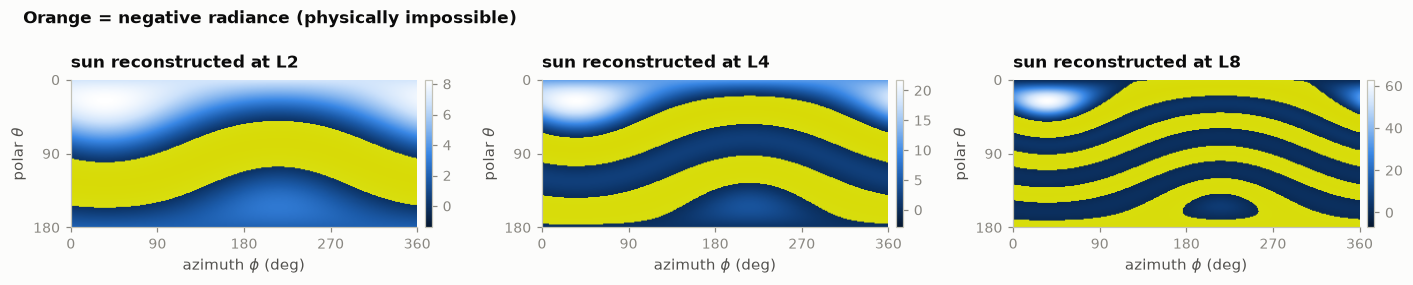

In [8]:
# Visualise where it goes negative.
fig, axes = plt.subplots(1, 3, figsize=(13.0, 2.6))
for ax, L in zip(axes, (2, 4, 8)):
    rec = sh.sh_to_equirect(coeffs["sun"][:(L+1)**2], 300, 150)[..., 0]
    neg = np.where(rec < 0, rec, np.nan)
    sp.show_equirect(rec, f"sun reconstructed at L{L}", ax=ax)
    ax.imshow(np.where(np.isnan(neg), np.nan, 1.0), cmap="autumn",
              extent=[0, 360, 180, 0], aspect="auto", alpha=0.85, vmin=0, vmax=1)
fig.suptitle("Orange = negative radiance (physically impossible)",
             x=0.02, ha="left", fontsize=11, weight="bold")
fig.tight_layout()

The bright sun is surrounded by a ring of negative light. In an engine this reads
as a dark halo around bright sources, and it gets *worse* in motion because the
ring moves with the light.

## 3. Windowing: the fix

Instead of a brick wall, taper the high bands smoothly to zero. Multiply each
band by a window coefficient $w_\ell$ that starts at 1 and decays:

$$c'_{\ell m} = w_\ell \, c_{\ell m}$$

Two standard choices, both in `shlib`:

$$w^{\text{Hanning}}_\ell = \tfrac12\left(1 + \cos\frac{\pi \ell}{W}\right)
\qquad
w^{\text{Lanczos}}_\ell = \frac{\sin(\pi \ell / W)}{\pi \ell / W}$$

$W$ is the window width. Smaller $W$ = more aggressive smoothing = less ringing but
more blur. This is a genuine trade, not a free fix — you are choosing to lose
sharpness to buy physical plausibility.

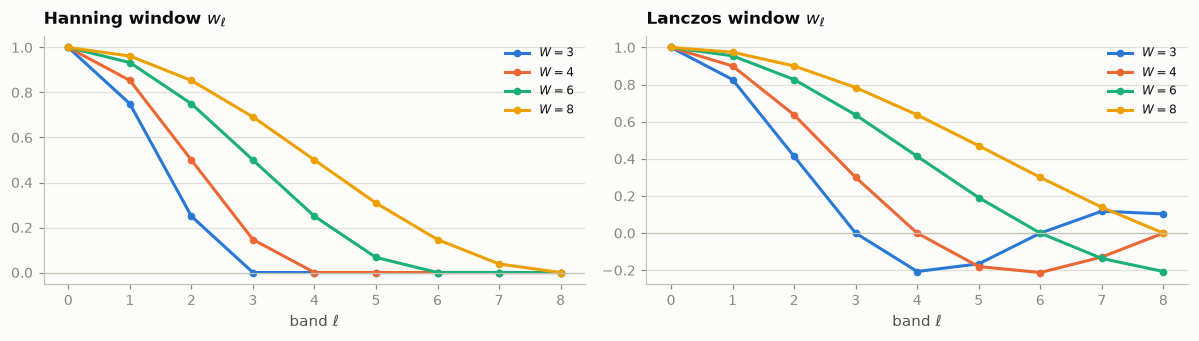

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.2))

ls = np.arange(0, 9)
for i, W in enumerate([3, 4, 6, 8]):
    hw = np.array([sh.hanning_window(np.eye((8+1)**2)[l*l+l], W)[l*l+l] for l in ls])
    lw = np.array([sh.lanczos_window(np.eye((8+1)**2)[l*l+l], W)[l*l+l] for l in ls])
    axes[0].plot(ls, hw, "o-", color=sp.SERIES[i], label=f"$W={W}$", ms=4)
    axes[1].plot(ls, lw, "o-", color=sp.SERIES[i], label=f"$W={W}$", ms=4)
for ax, t in zip(axes, ["Hanning window $w_\\ell$", "Lanczos window $w_\\ell$"]):
    ax.axhline(0, color=sp.AXIS, lw=0.8)
    ax.set_xlabel("band $\\ell$"); ax.set_title(t); ax.legend(fontsize=8)
fig.tight_layout()

(<Figure size 1650x286 with 8 Axes>,
 array([[<Axes: title={'left': 'no window (brick wall)\nmin = -2.9362'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'Hanning W=6\nmin = -0.3904'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'Hanning W=4\nmin = -0.0862'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'Lanczos W=5\nmin = -0.4163'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>]],
       dtype=object))

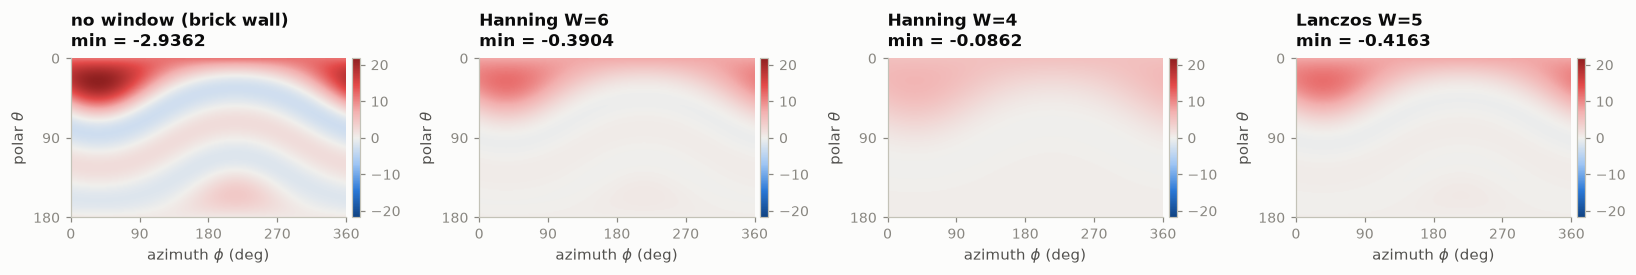

In [10]:
# Does it work? Reconstruct the sun at L4 with and without windowing.
L = 4
raw = coeffs["sun"][:(L+1)**2]
variants = [("no window (brick wall)", raw),
            ("Hanning W=6", sh.hanning_window(raw, 6.0)),
            ("Hanning W=4", sh.hanning_window(raw, 4.0)),
            ("Lanczos W=5", sh.lanczos_window(raw, 5.0))]

imgs, titles = [], []
for name, cc in variants:
    rec = sh.sh_to_equirect(cc, 300, 150)
    imgs.append(rec[..., 0])
    titles.append(f"{name}\nmin = {rec.min():+.4f}")
sp.show_images(imgs, titles, cols=4, signed=True, figsize=(15.0, 2.6))

In [11]:
print(f"{'variant':<26}{'min radiance':>14}{'RMS err vs truth':>19}")
print("-" * 60)
truth = sh.env_to_equirect(ss.ENVIRONMENTS['sun'], 300, 150)
for name, cc in variants:
    rec = sh.sh_to_equirect(cc, 300, 150)
    print(f"{name:<26}{rec.min():>+14.4f}{sh.relative_error(rec, truth)*100:>18.2f}%")

variant                     min radiance   RMS err vs truth
------------------------------------------------------------
no window (brick wall)           -2.9362             91.53%
Hanning W=6                      -0.3904             93.60%
Hanning W=4                      -0.0862             96.07%
Lanczos W=5                      -0.4163             93.66%


Two things to read carefully here.

**The RMS numbers are enormous — over 90% — for every variant.** That is not a bug.
The `sun` environment is a 120x-bright disc covering a tiny solid angle, and *no*
L4 reconstruction can represent it; the error is dominated by the spike we cannot
reproduce at all. RMS against a near-delta is close to meaningless. This is the
clearest possible illustration of notebook 05's thesis: **SH cannot represent
concentrated radiance.**

**Windowing makes RMS worse, not better** (91.5% → 96.1% at Hanning W=4), because we
deliberately threw away real signal. But it takes the minimum from $-2.94$ to
$-0.09$, nearly eliminating the impossible negative light.

That is the honest framing: **windowing trades accuracy for plausibility.** A
slightly-wrong image with no impossible values looks far better than a
slightly-less-wrong image with black halos ringing around every light.

## 4. Practical guidance

- Ringing scales with **contrast**. A sun 120x brighter than the sky rings hard; an
  overcast sky barely rings at all.
- The cheapest mitigation is often at bake time: clamp or soft-knee the environment
  before projecting, so the delta is less delta-like.
- Windowing is per-probe and free at runtime — it happens during the bake, so the
  shader is unchanged.
- **For diffuse-only probes you often need none of this**, because the cosine
  convolution in notebook 06 low-passes the signal anyway. Windowing matters most
  when SH is used for *specular* or for sharper BRDFs.

## 5. The setup for the punchline

Everything in this notebook measured how well SH represents **radiance**, and the
answer for sharp environments is: poorly.

But look again at what a light probe is asked to produce. Not $L(\boldsymbol\omega)$ —
irradiance $E(\mathbf{n})$, which is $L$ convolved with a very wide, very smooth
cosine lobe. Let's peek at what that convolution does to the spectrum:

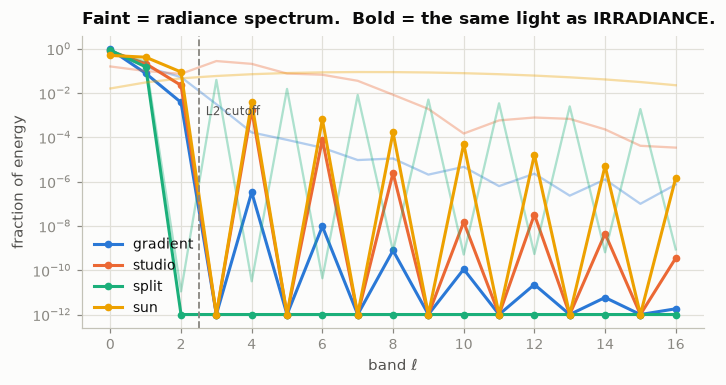

In [12]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
for i, k in enumerate(ENVS):
    c = coeffs[k]
    e_rad = np.array([(c[l*l:(l+1)**2]**2).sum() for l in range(LMAX+1)])
    ci = sh.convolve_cosine(c)
    e_irr = np.array([(ci[l*l:(l+1)**2]**2).sum() for l in range(LMAX+1)])
    ax.semilogy(range(LMAX+1), np.maximum(e_rad/e_rad.sum(), 1e-12),
                "-", color=sp.SERIES[i], alpha=0.35, lw=1.5)
    ax.semilogy(range(LMAX+1), np.maximum(e_irr/e_irr.sum(), 1e-12),
                "o-", color=sp.SERIES[i], label=k, ms=4)
ax.axvline(2.5, color=sp.MUTED, ls="--", lw=1.2)
ax.text(2.7, 1e-3, "L2 cutoff", fontsize=8, color=sp.SECONDARY)
ax.set_xlabel("band $\\ell$"); ax.set_ylabel("fraction of energy")
ax.set_title("Faint = radiance spectrum.  Bold = the same light as IRRADIANCE.")
ax.legend(); ax.grid(True, which="both", axis="both")
fig.tight_layout()

Look at what happened. The faint lines (radiance) trail off slowly. The bold lines
(irradiance) **fall off a cliff** — by band 3 they have essentially nothing left,
for *every* environment including the sun.

That collapse is why nine coefficients is enough. Notebook 06 explains exactly why
it happens and proves the "99%" claim.

---

**Next:** [06 — Irradiance: the convolution that makes light probes work](06_irradiance_convolution.ipynb)